# Análisis Exploratorio de Datos (EDA) — Taller 1

## Caso: Predicción de brotes de dengue

**Grupo 3**

| Integrante |
|------------|
| Juan Manuel Román Villa |
| Dora Valencia Martínez |
| Julian Aguilar Mayorga |
| Camilo Percy Ocampo |
| Viviana Fernández Payan |
| Giovanni Jaramillo Bolaños |
| Victor Manuel Hurtado López |

---

Este cuaderno es el **entregable completo** del Taller 1: problema, justificación, pregunta SMART e EDA. Sigue la estructura metodológica de la guía del profesor, adaptada a dengue.

> **Pregunta SMART + Hipótesis → Diccionario de datos → Visión general → Limpieza → Análisis univariado → Análisis bivariado → Conclusiones**

**Fuente única de este EDA:** archivo Excel SIVIGILA `Datos_2025_210.xlsx` (evento 210 — Dengue, año 2025). Todo el análisis y la interpretación viven en este notebook.


---
# 1. Definición del problema, justificación y Pregunta SMART

> *Etapa del flujo: **Pregunta SMART + Hipótesis***

## 1.1. Tabla de análisis del problema

| Campo | Contenido |
|-------|-----------|
| **Descripción del problema e impacto (con métrica)** | El aumento recurrente de casos de dengue genera **sobrecarga hospitalaria** y presión sobre la red de atención territorial. Nosotros usamos notificaciones SIVIGILA (INS, evento 210) para orientar vigilancia y priorización. **KPI medibles en este taller (Excel 2025):** volumen de casos; % confirmados; % hospitalización; concentración territorial (top deptos/municipios); perfil demográfico Valle vs nacional. **KPI de proyecto futuro:** precisión del modelo > 80 %; reducción de mortalidad y de tiempo de respuesta (requieren modelado). En 2025, `FEC_DEF` está 100 % nulo: **no medimos mortalidad aquí**. |
| **Tipo de analítica** | **Predictiva** (visión del proyecto) — anticipar territorios y periodos de mayor riesgo. En Taller 1 entregamos el **EDA** que sustenta esa fase. |
| **Caso similar (estado del arte)** | Delpino et al. (2026): modelos predictivos para severidad, hospitalización y mortalidad por dengue. Martin et al. (2026): factores climáticos como predictores de brotes (visión futura). Kumar et al. (2026): ML para detección temprana y alertas. |
| **Tipo de problema de IA** | **Regresión** — en fases posteriores, estimar casos agregados por municipio–semana. |
| **Datos usados en este taller** | **Única fuente:** `Datos_2025_210.xlsx` (~120.5k filas × ~70 variables en crudo; ~118k tras filtrar `FEC_NOT` fuera de 2025). Códigos enteros, fechas en texto, nulos estructurales (`FEC_DEF`, campos militares, etc.). |
| **Impacto en el negocio con métricas** | 1) Priorizar deptos/municipios de alta carga (top 10 ≈ 70 % de casos). 2) Anticipar ventanas de pico (ene–feb / primeras semanas). 3) Diferenciar perfiles territoriales (Valle vs nacional). |
| **Pregunta SMART** | Ver sección 1.3 abajo. |

## 1.2. Complejidad del problema

| Aspecto | Descripción |
|---------|-------------|
| **Variables involucradas** | ~70 columnas SIVIGILA: tiempo (`SEMANA`, `FEC_NOT`), territorio, edad/sexo, hospitalización, confirmación, estado del caso |
| **Procesos involucrados** | Vigilancia epidemiológica (notificación), atención hospitalaria, priorización territorial |
| **Dificultad técnica** | Media–alta para el EDA: fechas en texto con formato local, códigos categóricos como enteros, unidades de edad mixtas (`UNI_MED`), nulos estructurales y fechas fuera del año del archivo |

## 1.3. Pregunta SMART

> **Pregunta SMART:** ¿Puede un sistema de analítica predictiva basado en inteligencia artificial anticipar brotes de dengue con una **precisión superior al 80 %**, permitiendo reducir en al menos **20 %** la tasa de mortalidad y en **30 %** el tiempo de respuesta sanitaria en los territorios priorizados durante un **piloto de 6 meses**, utilizando datos epidemiológicos de **SIVIGILA (INS)**?

### Qué responde este EDA (2025) vs qué queda para modelado

| Responde el notebook ahora | Queda para fases posteriores |
|----------------------------|------------------------------|
| Calidad y estructura del Excel (~120.5k × ~70 vars) | Entrenar modelo con precisión > 80 % |
| Estacionalidad de casos (H1) | Otras fuentes externas (si el equipo las incorpora después) |
| Concentración territorial (H2) | Mortalidad (no disponible en este archivo) |
| Perfil demográfico Valle vs nacional (H3) | Regresión de casos municipio–semana |

## 1.4. Justificación del uso de IA / Ciencia de Datos


| Técnica | Aplicación en este trabajo | Pertinencia |
|---|---|---|
| Perfilamiento de datos | Dimensiones, tipos, nulos y duplicados | Verifica la calidad antes de interpretar resultados |
| Limpieza y transformación | Conversión de fechas, edades y variables binarias | Permite calcular indicadores consistentes |
| Analítica descriptiva | Conteos, porcentajes y promedios | Cuantifica el problema |
| Análisis temporal | Agrupación mensual | Identifica concentración de casos durante el año |
| Segmentación territorial | Ranking municipal y comparación con el promedio departamental | Responde directamente la pregunta SMART |
| Visualización | Tablas y gráficas en Jupyter; dashboard en Streamlit | Facilita la interpretación y comunicación |

La **IA generativa** se utilizó para estructurar el notebook, proponer y depurar código, diseñar las visualizaciones, documentar el procedimiento y organizar la interpretación. Su uso es pertinente porque acelera la construcción del prototipo; no reemplaza la validación humana. Se verificaron los nombres de las variables, el periodo, la fórmula del KPI, los filtros y la coherencia de los resultados.

Además, en el repositorio del equipo hay un **dashboard en Streamlit** (`app/dashboard.py`) para revisar de forma interactiva los datos limpios. El **Taller 1** se centra en **2025**, pero el dashboard permite cambiar de año (otros Excel SIVIGILA en `data/raw/`). En cada año se filtra `FEC_NOT` al año seleccionado. Se ejecuta con `uv run streamlit run app/dashboard.py` y complementa este notebook sin sustituir el EDA documentado aquí.

## 1.5. Hipótesis de trabajo

| ID | Hipótesis | Variables involucradas |
|----|-----------|------------------------|
| **H1** | Existe **estacionalidad**: los casos se concentran en ciertos meses/semanas epidemiológicas | `ANO`, `SEMANA`, `FEC_NOT`, `mes` |
| **H2** | Hay **heterogeneidad territorial**: algunos departamentos/municipios concentran más casos (y mayor carga de hospitalización) | `COD_DPTO_O`, `Departamento_ocurrencia`, `Municipio_ocurrencia`, `hospitalizado` |
| **H3** | En **Valle del Cauca** el perfil demográfico (`edad_anios`, `SEXO`) y la hospitalización difieren del agregado nacional | `edad_anios`, `SEXO`, `hospitalizado`, `Departamento_ocurrencia` |

## 1.6. Alcance de este EDA (Taller 1)

- **Fuente única:** `Datos_2025_210.xlsx` (evento 210 — Dengue, año **2025**)
- **No analizamos** otros años ni fuentes externas en este cuaderno
- Todo el diccionario, la limpieza y las conclusiones están **dentro de este notebook** (no hace falta el resto del repositorio para entender el entregable)


---
# 2. Carga del conjunto de datos

> *Etapa del flujo: **Carga de datos***

### Fuente utilizada en este EDA

| Fuente | Archivo | Estado |
|--------|---------|--------|
| **INS / SIVIGILA** (evento 210 — Dengue) | `Datos_2025_210.xlsx` | ✅ En uso (~120.5k registros crudos, año **2025**) |

> Este notebook analiza **solo** ese Excel. La carga se hace con utilidades del proyecto (`load_dengue`, modo `year`, `ANIO = 2025`).


In [1]:
# Importación de librerías
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Permite importar desde src/ al ejecutar el notebook
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DATA_RAW, DATA_PROCESSED
from src.load_data import load_dengue

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", None)

archivo_2025 = DATA_RAW / "Datos_2025_210.xlsx"
print(f"Proyecto: {PROJECT_ROOT}")
print(f"Fuente del EDA: {archivo_2025}")
print(f"Existe: {archivo_2025.exists()}")


Proyecto: /home/v1151969298/Documentos/development/proyecto_analisis_de_datos_I
Fuente del EDA: /home/v1151969298/Documentos/development/proyecto_analisis_de_datos_I/data/raw/Datos_2025_210.xlsx
Existe: True


In [1]:
# Carga del Excel SIVIGILA 2025 (única fuente de este EDA)
MODO = "year"
ANIO = 2025

df = load_dengue(MODO, year=ANIO)

print(f"Fuente: Datos_{ANIO}_210.xlsx")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria aprox.: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"COD_EVE: {df['COD_EVE'].unique()}")
print(f"Año en df: {sorted(df['ANO'].unique())}")


Fuente: Datos_2025_210.xlsx
Dimensiones: 120,564 filas × 70 columnas


---
# 3. Diccionario de datos

> *Etapa del flujo: **Diccionario de datos***

Documentamos aquí el **significado, tipo, relevancia y expectativa** de cada variable clave del Excel SIVIGILA 2025 (el diccionario completo del entregable está en esta sección).

Para cada variable:

- **Variable:** nombre de la columna
- **Tipo:** numérica, categórica, fecha
- **Descripción:** qué representa
- **Relevancia:** objetivo / predictora / contexto / descartar
- **Expectativa:** qué tan útil creemos que es para anticipar carga/brotes (**Alta / Media / Baja**)

## 3.1. Diccionario del conjunto de datos SIVIGILA (evento 210)

### Variables objetivo y de desenlace

| Variable | Tipo | Descripción | Relevancia | Expectativa |
|----------|------|-------------|------------|-------------|
| `CONSECUTIVE` | int | Identificador único del registro | Clave primaria | Baja |
| `confirmados` | categórico | Caso confirmado (1=Sí, 0=No) | Filtro de casos | Alta |
| `CON_FIN` / `Estado_final_de_caso` | categórico | Condición final del paciente | Desenlace clínico | Media |
| `FEC_DEF` | fecha | Fecha de defunción | Mortalidad (100 % nulos en 2025 → se descarta) | Baja |
| `PAC_HOS` | categórico | Hospitalizado (1=Sí, 2=No) | Severidad / carga clínica | Alta |
| `nom_est_f_caso` | texto | Estado final (lab, probable, etc.) | Clasificación | Media |

### Variables temporales

| Variable | Tipo | Descripción | Relevancia | Expectativa |
|----------|------|-------------|------------|-------------|
| `ANO` | int (temporal) | Año de notificación | Serie temporal | Media |
| `SEMANA` | int (temporal) | Semana epidemiológica | Agregación temporal | Alta |
| `FEC_NOT` | texto/fecha | Fecha de notificación | Convertir a datetime; base de `mes` | Alta |
| `INI_SIN` | texto/fecha | Inicio de síntomas | Latencia del brote | Media |

### Variables territoriales

| Variable | Tipo | Descripción | Relevancia | Expectativa |
|----------|------|-------------|------------|-------------|
| `COD_DPTO_O` / `Departamento_ocurrencia` | int/texto | Departamento de ocurrencia | Análisis territorial | Alta |
| `COD_MUN_O` / `Municipio_ocurrencia` | int/texto | Municipio de ocurrencia | Unidad de agregación | Alta |
| `AREA` | categórico | Urbana / Rural / Urbana-rural (1/2/3) | Contexto | Media |

### Variables demográficas y clínicas

| Variable | Tipo | Descripción | Relevancia | Expectativa |
|----------|------|-------------|------------|-------------|
| `EDAD` | int | Edad del paciente (unidad según `UNI_MED`) | Perfil epidemiológico | Media |
| `UNI_MED` | categórico | Unidad de edad (1=años, 2=meses, 3=días) | Normalizar a `edad_anios` | Alta |
| `SEXO` | texto | Sexo (M/F) | Perfil epidemiológico | Media |
| `TIP_CAS` | categórico | Tipo de caso (2=Probable, 3=Confirmado) | Clasificación | Media |


In [2]:
# Construimos el diccionario de variables clave como DataFrame (guía del profesor)
columnas_clave = [
    "CONSECUTIVE", "ANO", "SEMANA", "FEC_NOT", "EDAD", "UNI_MED", "SEXO",
    "COD_DPTO_O", "Departamento_ocurrencia", "COD_MUN_O", "Municipio_ocurrencia",
    "confirmados", "PAC_HOS", "CON_FIN", "FEC_DEF", "nom_est_f_caso", "TIP_CAS", "AREA",
]

diccionario = pd.DataFrame({
    "variable": columnas_clave,
    "tipo": [
        "int", "int (temporal)", "int (temporal)", "texto/fecha", "int", "categórico", "categórico",
        "int", "categórico", "int", "categórico",
        "categórico", "categórico", "categórico", "fecha", "categórico", "categórico", "categórico",
    ],
    "descripcion": [
        "Identificador único del registro",
        "Año de notificación",
        "Semana epidemiológica",
        "Fecha de notificación del caso",
        "Edad del paciente (según UNI_MED)",
        "Unidad de edad (1=años, 2=meses, 3=días)",
        "Sexo del paciente (M/F)",
        "Código DANE del departamento de ocurrencia",
        "Nombre del departamento de ocurrencia",
        "Código DANE del municipio de ocurrencia",
        "Nombre del municipio de ocurrencia",
        "Caso confirmado (1=Sí, 0=No)",
        "Hospitalizado (1=Sí, 2=No)",
        "Condición final del paciente",
        "Fecha de defunción (100% nulos en 2025)",
        "Estado final del caso (lab, probable, etc.)",
        "Tipo de caso (2=Probable, 3=Confirmado)",
        "Área (1=Urbana, 2=Rural, 3=Urbana-rural)",
    ],
    "relevancia": [
        "Clave primaria", "Serie temporal", "Agregación temporal", "Convertir a datetime",
        "Perfil epidemiológico", "Normalizar edad", "Perfil epidemiológico",
        "Análisis territorial", "Reportes/mapas", "Unidad de agregación", "Reportes/mapas",
        "Filtro de casos", "Severidad", "Desenlace clínico", "Descartar (nulos)", "Clasificación",
        "Clasificación", "Contexto",
    ],
    "expectativa": [
        "Baja", "Media", "Alta", "Alta",
        "Media", "Alta", "Media",
        "Alta", "Alta", "Alta", "Alta",
        "Alta", "Alta", "Media", "Baja", "Media",
        "Media", "Media",
    ],
})

diccionario


Diccionario construido: 18 variables clave con Expectativa Alta/Media/Baja


---
# 4. Visión general del conjunto de datos

> *Etapa del flujo: **Visión general (formato, nombres, tipos, unidades, columnas redundantes)***

Antes de entrar al detalle, obtenemos una **fotografía global** del dataset.

## 4.1. Primeras filas del conjunto de datos

In [6]:
# El método head() permite una inspección visual rápida de los registros.
df.head(10)

,CONSECUTIVE,COD_EVE,FEC_NOT,SEMANA,ANO,COD_PRE,COD_SUB,EDAD,UNI_MED,SEXO,COD_PAIS_O,COD_DPTO_O,COD_MUN_O,AREA,OCUPACION,TIP_SS,COD_ASE,PER_ETN,GRU_POB,nom_grupo,estrato,GP_DISCAPA,GP_DESPLAZ,GP_MIGRANT,GP_CARCELA,GP_GESTAN,sem_ges,GP_INDIGEN,GP_POBICFB,GP_MAD_COM,GP_DESMOVI,GP_PSIQUIA,GP_VIC_VIO,GP_OTROS,fuente,COD_PAIS_R,COD_DPTO_R,COD_MUN_R,COD_DPTO_N,COD_MUN_N,FEC_CON,INI_SIN,TIP_CAS,PAC_HOS,FEC_HOS,CON_FIN,FEC_DEF,AJUSTE,FECHA_NTO,CBMTE,FEC_ARC_XL,FEC_AJU,FM_FUERZA,FM_UNIDAD,FM_GRADO,confirmados,va_sispro,Estado_final_de_caso,nom_est_f_caso,Nombre_upgd,Pais_ocurrencia,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Pais_residencia,Departamento_residencia,Municipio_residencia,Departamento_Notificacion,Municipio_notificacion,archivo_origen
0,23659,210,30/03/2025 12:00:00 a. m.,12,2025,8173600067,1,17,1,F,170,81,65,1,99999.07,S,EPSS41,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,81,736,81,81736,28/03/2025 12:00:00 a. m.,22/03/2025 12:00:00 a. m.,3,1,28/03/2025 12:00:00 a. m.,1,NaN,0,28/01/2008 12:00:00 a. m.,NaN,2/04/2025 12:00:00 a. m.,2/04/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,ESE HOSPITAL DEL SARARE,COLOMBIA,DENGUE,ARAUCA,ARAUQUITA,COLOMBIA,ARAUCA,SARAVENA,ARAUCA,SARAVENA,2025
1,28950,210,7/01/2025 12:00:00 a. m.,2,2025,2300101129,2,15,1,F,170,23,466,1,99999.05,S,EPSS37,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,23,466,23,23001,7/01/2025 12:00:00 a. m.,7/01/2025 12:00:00 a. m.,3,1,7/01/2025 12:00:00 a. m.,1,NaN,0,25/12/2009 12:00:00 a. m.,NaN,10/01/2025 12:00:00 a. m.,10/01/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,CENTRO CARDIOINFANTIL IPS EU,COLOMBIA,DENGUE,CORDOBA,MONTELIBANO,COLOMBIA,CORDOBA,MONTELIBANO,CORDOBA,MONTERIA,2025
2,28949,210,18/08/2025 12:00:00 a. m.,34,2025,2300100542,1,15,1,F,170,23,580,1,99999.04,S,ESS024,6,NaN,...,1,2,2,2,2,1,34,2,2,2,2,2,2,2,1,170,23,580,23,23001,18/08/2025 12:00:00 a. m.,18/08/2025 12:00:00 a. m.,3,1,18/08/2025 12:00:00 a. m.,1,NaN,0,3/10/2009 12:00:00 a. m.,NaN,22/08/2025 12:00:00 a. m.,22/08/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,CLINICA MONTERIA SA,COLOMBIA,DENGUE,CORDOBA,PUERTO LIBERTADOR,COLOMBIA,CORDOBA,PUERTO LIBERTADOR,CORDOBA,MONTERIA,2025
3,29728,210,8/01/2025 12:00:00 a. m.,2,2025,2300100487,2,3,1,M,170,5,604,1,99999.07,S,ESS024,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,5,604,23,23001,8/01/2025 12:00:00 a. m.,7/01/2025 12:00:00 a. m.,3,1,8/01/2025 12:00:00 a. m.,1,NaN,0,25/01/2021 12:00:00 a. m.,NaN,15/01/2025 12:00:00 a. m.,15/01/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,CLINICA MATERNO INFANTIL CASA DEL NIÑO LTDA,COLOMBIA,DENGUE,ANTIOQUIA,REMEDIOS,COLOMBIA,ANTIOQUIA,REMEDIOS,CORDOBA,MONTERIA,2025
4,29813,210,27/01/2025 12:00:00 a. m.,3,2025,1300100085,1,20,1,F,170,13,1,1,99999.05,S,ESS207,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,13,1,13,13001,24/01/2025 12:00:00 a. m.,18/01/2025 12:00:00 a. m.,2,1,24/01/2025 12:00:00 a. m.,1,NaN,3,31/01/2004 12:00:00 a. m.,NaN,4/03/2025 12:00:00 a. m.,4/03/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,CLINICA CARTAGENA DEL MAR S.A.,COLOMBIA,DENGUE,BOLIVAR,CARTAGENA,COLOMBIA,BOLIVAR,CARTAGENA,BOLIVAR,CARTAGENA,2025
5,28988,210,12/12/2025 12:00:00 a. m.,50,2025,1367000076,1,20,1,M,170,13,670,3,99999.04,S,CCF055,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,13,670,13,13670,12/12/2025 12:00:00 a. m.,7/12/2025 12:00:00 a. m.,3,2,NaN,1,NaN,0,30/05/2005 12:00:00 a. m.,NaN,16/12/2025 12:00:00 a. m.,16/12/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,ESE HOSPITAL LOCAL SAN PABLO,COLOMBIA,DENGUE,BOLIVAR,SAN PABLO,COLOMBIA,BOLIVAR,SAN PABLO,BOLIVAR,SAN PABLO,2025
6,1872,210,15/09/2025 12:00:00 a. m.,37,2025,2300100487,2,16,1,M,170,23,1,1,99999.05,S,ESS207,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,23,1,23,23001,15/09/2025 12:00:00 a. m.,10/09/2025 12:00:00 a. m.,3,1,15/09/2025 12:00:00 a. m.,1,NaN,0,3/04/2009 12:00:00 a. m.,NaN,16/09/2025 12:00:00 a. m.,16/09/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirma

## 4.2. Estructura, tipos de datos y memoria

Revisar si columnas numéricas aparecen como `object` (fechas en texto, códigos mixtos).

In [7]:
# info() resume registros no nulos y tipo de dato por columna.
df.info()
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

<class 'pandas.DataFrame'>
RangeIndex: 120564 entries, 0 to 120563
Data columns (total 70 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   CONSECUTIVE                120564 non-null  int64   
 1   COD_EVE                    120564 non-null  int64   
 2   FEC_NOT                    120564 non-null  category
 3   SEMANA                     120564 non-null  int64   
 4   ANO                        120564 non-null  int64   
 5   COD_PRE                    120564 non-null  int64   
 6   COD_SUB                    120564 non-null  int64   
 7   EDAD                       120564 non-null  int64   
 8   UNI_MED                    120564 non-null  int64   
 9   SEXO                       120564 non-null  category
 10  COD_PAIS_O                 120564 non-null  int64   
 11  COD_DPTO_O                 120564 non-null  int64   
 12  COD_MUN_O                  120564 non-null  int64   
 13  AREA                     

## 4.3. Dimensiones, columnas y valores únicos

Evaluar cardinalidad de variables categóricas (departamentos, municipios, UPGD).

In [10]:
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
print("-" * 60)
print("Años:", sorted(df["ANO"].unique()))
# FEC_NOT puede venir como texto o category: usamos str para el rango en esta etapa
fec_not = df["FEC_NOT"].astype(str)
print("Rango fechas:", fec_not.min(), "→", fec_not.max())
print("Departamentos:", df["Departamento_ocurrencia"].nunique())
print("Municipios:", df["Municipio_ocurrencia"].nunique())
print("Semanas epidemiológicas:", df["SEMANA"].nunique())
print("-" * 60)
df.nunique().sort_values(ascending=False).head(15)

Filas: 120564 | Columnas: 70
------------------------------------------------------------
Años: [np.int64(2025)]
Rango fechas: 1/01/2025 12:00:00 a. m. → 9/12/2025 12:00:00 a. m.
Departamentos: 33
Municipios: 840
Semanas epidemiológicas: 53
------------------------------------------------------------


CONSECUTIVE               120564
FECHA_NTO                  25666
Nombre_upgd                 2527
COD_PRE                     2116
Municipio_residencia         891
Municipio_ocurrencia         840
COD_MUN_N                    813
Municipio_notificacion       762
OCUPACION                    596
COD_MUN_R                    521
COD_MUN_O                    505
FEC_AJU                      454
FEC_ARC_XL                   452
FEC_NOT                      437
FEC_CON                      398
dtype: int64

## 4.4. Estadísticos descriptivos preliminares

**Sobre columnas a descartar o usar con cuidado:**

- **Identificadores:** `CONSECUTIVE` — clave, no predictor
- **Redundantes:** pares código/nombre territorial (`COD_DPTO_O` vs `Departamento_ocurrencia`)
- **100 % nulos:** `FEC_DEF`, `GRU_POB`, `CBMTE` — se excluyen en la limpieza
- **`EDAD` cruda:** no la interpretamos aquí; depende de `UNI_MED` (años/meses/días). La edad comparable es `edad_anios` (sección 5.4)
- ***Data leakage*:** variables posteriores al desenlace que no estarían disponibles al predecir


In [ ]:
# Estadísticos preliminares: SEMANA es usable; EDAD es cruda (ver UNI_MED → edad_anios en §5.4)
cols_describe = ["EDAD", "SEMANA"]
print("Nota: EDAD aún no está normalizada; no interpretar media/mediana hasta crear edad_anios.")
df[cols_describe].describe().T


,count,mean,std,min,25%,50%,75%,max
EDAD,120564.0,22.588982,18.528527,1.0,9.0,16.0,31.0,104.0
SEMANA,120564.0,22.259057,15.412488,1.0,9.0,20.0,34.0,53.0
ANO,120564.0,2025.000000,0.000000,2025.0,2025.0,2025.0,2025.0,2025.0


In [ ]:
# Resumen de variables categóricas clave (incluye códigos enteros: PAC_HOS, etc.)
cols_cat = [
    "SEXO", "PAC_HOS", "confirmados", "TIP_CAS", "AREA",
    "nom_est_f_caso", "Departamento_ocurrencia",
]
for col in cols_cat:
    print(f"\n--- {col} (top 5) ---")
    print(df[col].value_counts().head())


--- SEXO (top 5) ---
SEXO
M    62938
F    57626
Name: count, dtype: int64

--- nom_est_f_caso (top 5) ---
nom_est_f_caso
Confirmado por laboratorio            85842
Probable                              30074
Confirmado por Nexo Epidemiológico     4648
Name: count, dtype: int64

--- Departamento_ocurrencia (top 5) ---
Departamento_ocurrencia
BOLIVAR            11668
SANTANDER          10938
CORDOBA            10450
META               10266
NORTE SANTANDER     8415
Name: count, dtype: int64

--- TIP_SS (top 5) ---
TIP_SS
S    67545
C    45618
P     5342
N     1329
I      601
Name: count, dtype: int64


---
# 5. Limpieza y preparación de los datos

> *Etapa del flujo: preparación previa al análisis (valores perdidos, formato)*

## 5.1. Identificación de valores perdidos

### Paso 1 — Conteo de nulos por columna

In [11]:
nulos = df.isnull().sum()
nulos[nulos > 0].sort_values(ascending=False)

GRU_POB      120564
FEC_DEF      120564
CBMTE        120564
FM_FUERZA    119949
FM_UNIDAD    119949
FM_GRADO     119949
FEC_HOS       75710
COD_ASE        1930
dtype: int64

### Paso 2 — Porcentaje de valores perdidos por columna

In [12]:
pct_nulos = (df.isnull().mean() * 100).round(2)
pct_nulos[pct_nulos > 0].sort_values(ascending=False)

GRU_POB      100.00
FEC_DEF      100.00
CBMTE        100.00
FM_FUERZA     99.49
FM_UNIDAD     99.49
FM_GRADO      99.49
FEC_HOS       62.80
COD_ASE        1.60
dtype: float64

## 5.2. Tratamiento de los valores perdidos

Tabla de justificación (estilo guía del profesor):

| Columna | Faltantes / hallazgo | Estrategia | Justificación |
|---------|----------------------|------------|---------------|
| `GRU_POB`, `CBMTE`, `FM_FUERZA`, `FM_UNIDAD`, `FM_GRADO` | ~100 % nulos | **Drop columna** | Sin información útil para el EDA |
| `FEC_DEF` | 100 % nulos en 2025 | **Drop columna** | No permite analizar mortalidad con este archivo |
| `COD_ASE` | Alta proporción de nulos / poco usable | **Drop columna** | No aporta al análisis territorial ni clínico del taller |
| `FEC_HOS` | Nulos frecuentes | **Conservar** | Nulo = no hospitalizado (esperado); no imputamos |
| `COD_MUN_O`, `FEC_NOT` | Críticos si faltan | **Dropna filas** | Sin municipio o fecha no hay análisis espacial/temporal fiable |
| Resto de variables clave (`SEXO`, `EDAD`, `PAC_HOS`, etc.) | Bien pobladas | **Conservar** | Base del perfil demográfico y clínico |


In [3]:
df_limpio = df.copy()

# Drop: columnas vacías / sin utilidad (GRU_POB, CBMTE, campos militares, FEC_DEF, COD_ASE)
cols_vacias = ["GRU_POB", "CBMTE", "FEC_DEF", "FM_FUERZA", "FM_UNIDAD", "FM_GRADO", "COD_ASE"]
df_limpio = df_limpio.drop(columns=[c for c in cols_vacias if c in df_limpio.columns])

# Dropna: filas sin municipio o fecha de notificación (críticos para H1/H2)
# FEC_HOS se conserva con nulos (no hospitalizado)
filas_antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=["COD_MUN_O", "FEC_NOT"])
print(f"Columnas eliminadas: {cols_vacias}")
print(f"Filas eliminadas: {filas_antes - len(df_limpio):,}")
print(f"Filas restantes: {len(df_limpio):,}")


Columnas eliminadas: ['GRU_POB', 'CBMTE', 'FEC_DEF', 'FM_FUERZA', 'FM_UNIDAD', 'FM_GRADO', 'COD_ASE']
Filas eliminadas: 0
Filas restantes: 120,564


### Verificación: estado de valores perdidos tras limpieza

In [14]:
# Top columnas con nulos restantes
resto = df_limpio.isnull().sum()
resto[resto > 0].sort_values(ascending=False).head(10)

FEC_HOS    75710
dtype: int64

## 5.3. Corrección del formato de los datos

Convertimos fechas en texto a `datetime` con formato explícito (`dd/mm/yyyy HH:MM:SS`) para evitar ambigüedad.

Además, documentamos y **filtramos** registros cuya `FEC_NOT` cae fuera de **2025** (inconsistencias de digitación o notificación tardía/anticipada). El EDA temporal de este taller se acota al año del Excel.


In [4]:
def parsear_fecha(serie):
    """Convierte fechas SIVIGILA (dd/mm/yyyy con 'a. m.' / 'p. m.') a datetime."""
    limpia = (
        serie.astype(str)
        .str.replace("\xa0", " ", regex=False)  # NBSP de Excel
        .str.replace(r"\s*a\.\s*m\.", "", regex=True)
        .str.replace(r"\s*p\.\s*m\.", "", regex=True)
        .str.strip()
    )
    # Formato explícito (con hora); fallback a solo fecha
    dt = pd.to_datetime(limpia, format="%d/%m/%Y %H:%M:%S", errors="coerce")
    mask = dt.isna() & limpia.ne("nan") & limpia.ne("NaT") & limpia.ne("") & limpia.ne("None")
    if mask.any():
        dt = dt.copy()
        dt.loc[mask] = pd.to_datetime(limpia.loc[mask], format="%d/%m/%Y", errors="coerce")
    return dt

cols_fecha = ["FEC_NOT", "INI_SIN", "FEC_HOS", "FEC_CON", "FECHA_NTO"]
for col in cols_fecha:
    if col in df_limpio.columns:
        df_limpio[col] = parsear_fecha(df_limpio[col])

print("FEC_NOT convertida:", df_limpio["FEC_NOT"].dtype)
print("Rango crudo:", df_limpio["FEC_NOT"].min(), "→", df_limpio["FEC_NOT"].max())

# Fechas fuera del año de análisis (inconsistencias de notificación / digitación)
fuera_anio = df_limpio["FEC_NOT"].notna() & (df_limpio["FEC_NOT"].dt.year != ANIO)
n_fuera = int(fuera_anio.sum())
print(f"Registros con FEC_NOT fuera de {ANIO}: {n_fuera:,} ({n_fuera/len(df_limpio)*100:.2f}%)")
if n_fuera > 0:
    print(df_limpio.loc[fuera_anio, "FEC_NOT"].dt.year.value_counts().sort_index())

# Conservamos solo notificaciones del año del Excel para el EDA temporal/territorial
filas_antes = len(df_limpio)
df_limpio = df_limpio.loc[~fuera_anio].copy()
print(f"Filas filtradas (FEC_NOT fuera de {ANIO}): {filas_antes - len(df_limpio):,}")
print(f"Filas restantes: {len(df_limpio):,}")
print("Rango final FEC_NOT:", df_limpio["FEC_NOT"].min(), "→", df_limpio["FEC_NOT"].max())
df_limpio[["FEC_NOT", "INI_SIN", "FEC_HOS"]].head()


FEC_NOT convertida: datetime64[ns]
Rango crudo: 2024-12-29 12:00:00 → 2026-03-27 12:00:00
Registros con FEC_NOT fuera de 2025: 2,444 (2.03%)
FEC_NOT
2024     170
2026    2274
Filas filtradas (FEC_NOT fuera de 2025): 2,444
Filas restantes: 118,120
Rango final FEC_NOT: 2025-01-01 12:00:00 → 2025-12-31 12:00:00


## 5.4. Creación de nuevas columnas (features derivadas)

In [17]:
def edad_en_anios(row):
    if row["UNI_MED"] == 1:
        return row["EDAD"]
    if row["UNI_MED"] == 2:
        return row["EDAD"] / 12
    return row["EDAD"] / 365

df_limpio["edad_anios"] = df_limpio.apply(edad_en_anios, axis=1)
df_limpio["mes"] = df_limpio["FEC_NOT"].dt.month
df_limpio["trimestre"] = df_limpio["FEC_NOT"].dt.quarter
df_limpio["hospitalizado"] = df_limpio["PAC_HOS"] == 1
df_limpio["confirmado"] = df_limpio["confirmados"] == 1
df_limpio["depto_mun"] = (
    df_limpio["COD_DPTO_O"].astype(str).str.zfill(2)
    + df_limpio["COD_MUN_O"].astype(str).str.zfill(3)
)

df_limpio[["EDAD", "UNI_MED", "edad_anios", "mes", "hospitalizado", "confirmado", "depto_mun"]].head()

,EDAD,UNI_MED,edad_anios,mes,hospitalizado,confirmado,depto_mun
0,17,1,17.0,3,True,True,81065
1,15,1,15.0,1,True,True,23466
2,15,1,15.0,8,True,True,23580
3,3,1,3.0,1,True,True,05604
4,20,1,20.0,1,True,True,13001


In [18]:
# Exportar dataset limpio del año para el equipo
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
ruta_limpio = DATA_PROCESSED / f"dengue_sivigila_{ANIO}_limpio.parquet"
df_limpio.to_parquet(ruta_limpio, index=False)
print(f"Exportado: {ruta_limpio}")
print(f"Filas: {len(df_limpio):,} | Columnas: {df_limpio.shape[1]}")

Exportado: /home/v1151969298/Documentos/development/proyecto_analisis_de_datos_I/data/processed/dengue_sivigila_2025_limpio.parquet
Filas: 120,564 | Columnas: 69


Con esto concluye la etapa de limpieza. Disponemos de un conjunto **completo, con tipos correctos y variables derivadas** listo para el análisis exploratorio.

---
# 6. Análisis univariado

> *Etapa del flujo: **Análisis univariado***

## 6.1. Variables objetivo: casos, hospitalización y perfil temporal

**Preguntas guía** (se responden al ejecutar las celdas de abajo; interpretación en la celda markdown siguiente):

| Pregunta guía | Dónde se responde | Hipótesis / KPI |
|----------------|-------------------|-----------------|
| ¿Cómo se distribuyen los casos por mes y semana epidemiológica? | Gráficos de casos por mes y por `SEMANA` + interpretación §6.1; refuerzo en §7.4 | **H1** (estacionalidad) |
| ¿Cuántas hospitalizaciones hay? | Resumen `hospitalizado` / % hosp. en la celda de desenlace | KPI clínico del taller |
| ¿Qué proporción son casos confirmados? | Resumen `confirmado` / `nom_est_f_caso` | KPI de calidad/clasificación |


In [5]:
# Resumen de variables de desenlace
print("Total casos:", len(df_limpio))
print("Casos confirmados:", df_limpio["confirmado"].sum(), f"({df_limpio['confirmado'].mean()*100:.1f}%)")
print("Hospitalizados:", df_limpio["hospitalizado"].sum(), f"({df_limpio['hospitalizado'].mean()*100:.1f}%)")
print()
print("Estado final del caso:")
print(df_limpio["nom_est_f_caso"].value_counts())

Total casos: 118120
Casos confirmados: 88565 (75.0%)
Hospitalizados: 43920 (37.2%)


In [6]:
# Casos por mes — 2025
casos_por_mes = df_limpio.groupby("mes").size()
casos_por_mes.plot(kind="bar", color="steelblue", title=f"Casos de dengue por mes — {ANIO}")
plt.xlabel("Mes")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Casos por mes — 2025 (evidencia H1):
mes
1     15984
2     13811
3     11804
4     11513
5     12338
6      9600
7      9436
8      6938
9      6149
10     5722
11     6985
12     7840


> **Lectura rápida:** enero y febrero concentran el mayor volumen de casos en 2025; luego cae hacia el segundo semestre (**H1**).


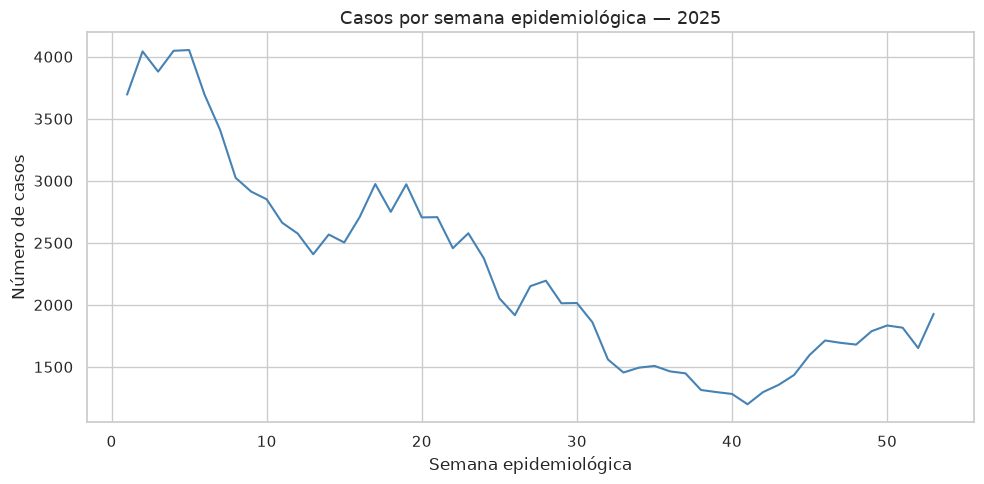

In [22]:
# Casos por semana epidemiológica — 2025
casos_por_semana = df_limpio.groupby("SEMANA").size()
casos_por_semana.plot(color="steelblue", title=f"Casos por semana epidemiológica — {ANIO}")
plt.xlabel("Semana epidemiológica")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

> **Lectura rápida:** la serie semanal muestra el mismo patrón: carga alta al inicio del año y descenso posterior (**H1**).


**Interpretación §6.1 (2025) — respuestas a las preguntas guía:**

| Pregunta | Respuesta con lo ejecutado | Hipótesis |
|----------|----------------------------|-----------|
| ¿Cómo se distribuyen los casos por mes/semana? | Pico en **enero–febrero** y en las **primeras semanas epidemiológicas**; luego descenso hacia el segundo semestre, valle ~sep–oct y leve repunte al cierre | **H1 confirmada** (patrón estacional intra-anual) |
| ¿Cuántas hospitalizaciones hay? | Alrededor de **37 %** de los casos están hospitalizados (`hospitalizado`) | Carga clínica (apoya H2/H3 al cruzar por territorio) |
| ¿Qué proporción son confirmados? | Cerca de **75 %** confirmados | KPI de clasificación |

**Calidad temporal:** filtramos **~2.4k** registros con `FEC_NOT` fuera de 2025 para no contaminar la estacionalidad.


## 6.2. Variables numéricas continuas

Variables: `edad_anios`, `SEMANA`.

**Preguntas guía:**
- ¿Cómo se distribuye la edad de los casos? → histograma/boxplot + `describe` (celda siguiente). Alimenta **H3** (perfil demográfico).
- ¿Hay valores extremos en edad o semana? → §6.2.1 (IQR). No eliminamos outliers automáticamente.


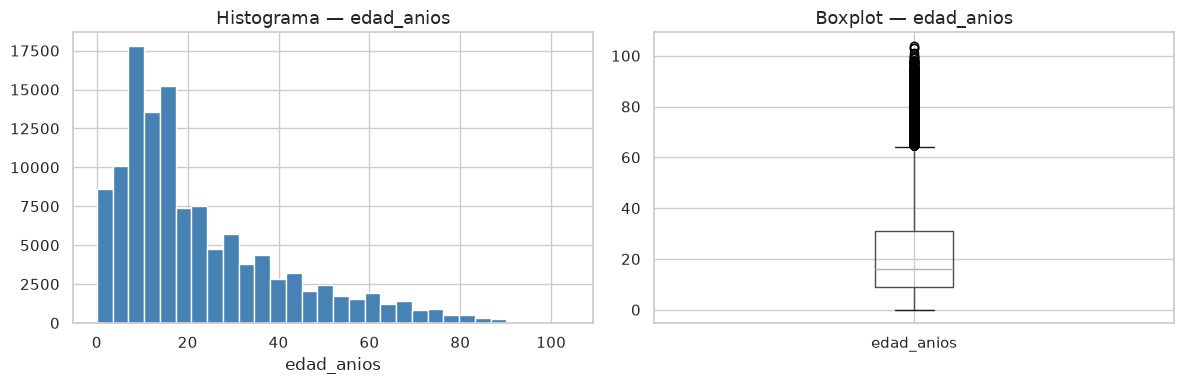

count    120564.000000
mean         22.487507
std          18.625811
min           0.002740
25%           9.000000
50%          16.000000
75%          31.000000
max         104.000000
Name: edad_anios, dtype: float64

In [20]:
def analizar_variable_continua(columna, data=df_limpio):
    """Muestra estadísticos, histograma y boxplot de una variable continua."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    data[columna].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="white")
    axes[0].set_title(f"Histograma — {columna}")
    axes[0].set_xlabel(columna)
    data.boxplot(column=columna, ax=axes[1])
    axes[1].set_title(f"Boxplot — {columna}")
    plt.tight_layout()
    plt.show()
    display(data[columna].describe())

analizar_variable_continua("edad_anios")

> **Lectura rápida (`edad_anios`):** distribución **sesgada a la derecha** (más niños/jóvenes). La mediana queda cerca de la adolescencia; el boxplot marca muchos puntos altos (>~65) como atípicos por IQR, pero son edades plausibles de adultos mayores — no los borramos.


### 6.2.1. Cuantificación de outliers (IQR)

> La detección de outliers **no implica** eliminación automática. Documentar y justificar.

In [21]:
def contar_outliers_iqr(columna, data=df_limpio):
    q1, q3 = data[columna].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (data[columna] < q1 - 1.5 * iqr) | (data[columna] > q3 + 1.5 * iqr)
    n = mask.sum()
    return n, len(data), n / len(data) * 100

for col in ["edad_anios", "SEMANA"]:
    n, total, pct = contar_outliers_iqr(col)
    print(f"{col}: {n:,} outliers ({pct:.2f}% de {total:,} registros)")

print("\n--- Revisión de extremos en edad_anios ---")
print("Mínimos (posibles neonatos):")
display(df_limpio.nsmallest(10, "edad_anios")[["EDAD", "UNI_MED", "edad_anios"]])

print("Máximos (edad avanzada):")
display(df_limpio.nlargest(10, "edad_anios")[["EDAD", "UNI_MED", "edad_anios"]])

print("Distribución de UNI_MED (1=años, 2=meses, 3=días):")
print(df_limpio["UNI_MED"].value_counts().sort_index())

print("\nChequeos rápidos:")
print("< 1 año:", (df_limpio["edad_anios"] < 1).sum())
print(">= 90 años:", (df_limpio["edad_anios"] >= 90).sum())
print(">= 100 años:", (df_limpio["edad_anios"] >= 100).sum())

edad_anios: 5,258 outliers (4.36% de 120,564 registros)
SEMANA: 0 outliers (0.00% de 120,564 registros)


## 6.3. Variables categóricas

Variables: `SEXO`, `AREA`, `Departamento_ocurrencia` (y contexto clínico si aplica).

**Preguntas guía:**
- ¿Cómo se reparte el sexo y el área? → barras/`value_counts` (celda siguiente).
- ¿Qué departamentos concentran más casos? → top 10 (celda siguiente). Responde **H2**.


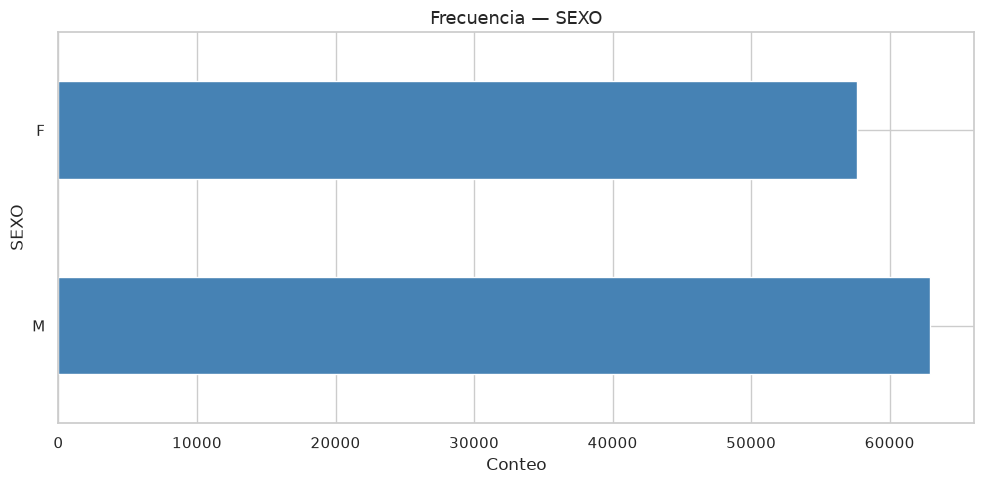

,conteo
SEXO,
M,62938
F,57626


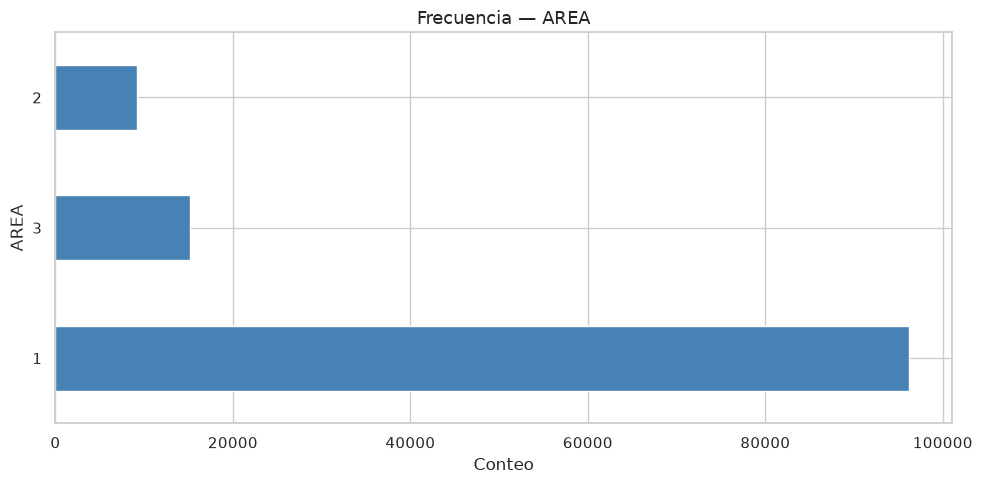

,conteo
AREA,
1,96192
3,15191
2,9181


In [22]:
MAPEO_CATEGORIAS = {
    "SEXO": {"M": "M — Masculino", "F": "F — Femenino"},
    "AREA": {1: "1 — Urbana", 2: "2 — Rural", 3: "3 — Urbana-rural"},
}

def analizar_variable_categorica(columna, data=df_limpio, top_n=15, mapeo=None):
    serie = data[columna]
    if mapeo is not None:
        serie = serie.map(mapeo).fillna(serie.astype(str))
    freq = serie.value_counts().head(top_n)
    freq.plot(kind="barh", color="steelblue", title=f"Frecuencia — {columna}")
    plt.xlabel("Conteo")
    plt.tight_layout()
    plt.show()
    display(freq.to_frame("conteo"))

for col in ["SEXO", "AREA"]:
    analizar_variable_categorica(col, mapeo=MAPEO_CATEGORIAS.get(col))

> **Lectura rápida:** `SEXO` está relativamente equilibrado (leve predominio masculino). `AREA` muestra predominio **urbano**.


In [7]:
# Top 10 departamentos por número de casos
top_deptos = df_limpio["Departamento_ocurrencia"].value_counts().head(10)
top_deptos.plot(kind="barh", color="steelblue", title=f"Top 10 departamentos — {ANIO}")
plt.xlabel("Número de casos")
plt.tight_layout()
plt.show()
top_deptos

Top 10 departamentos — evidencia H2:
Departamento_ocurrencia
BOLIVAR            11260
SANTANDER          10788
CORDOBA            10299
META               10121
NORTE SANTANDER     8276
ATLANTICO           7770
ANTIOQUIA           7545
VALLE               7441
TOLIMA              5260
CESAR               4144
Share top10: 70.2%


> **Lectura rápida:** Bolívar, Santander y Córdoba lideran el conteo; el top 10 concentra gran parte de las notificaciones (**H2**).


**Interpretación §6.2–6.3 (2025):**

| Pregunta / foco | Respuesta | Hipótesis |
|-----------------|-----------|-----------|
| Perfil demográfico (edad, sexo) | Leve predominio de hombres (**52.2 %** vs **47.8 %**). Con `edad_anios`: media **~22.5**, mediana **16** (sesgo a la derecha: más jóvenes) | Base para **H3** |
| Heterogeneidad territorial | Lideran **Bolívar, Santander y Córdoba**; el top 10 ≈ **70 %** de notificaciones | **H2 confirmada** (conteo univariado) |


---
# 7. Análisis bivariado

> *Etapa del flujo: **Análisis bivariado***

Aquí cruzamos variables para **contrastar H1–H3** (no solo describir una columna).

## 7.1. Matriz de correlación (variables numéricas)

**Pregunta guía:** ¿Hay relaciones lineales útiles entre edad y variables temporales?  
**Respuesta esperada:** `SEMANA`–`mes` alta por construcción; edad casi no correlaciona con semana/mes (poca señal lineal).


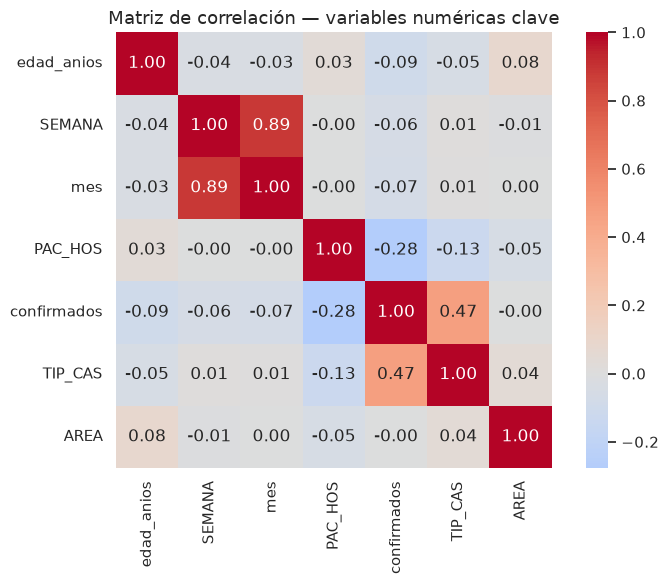

In [23]:
# Correlación de variables realmente numéricas/temporales
cols_num = ["edad_anios", "SEMANA", "mes"]
corr = df_limpio[cols_num].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación — edad y variables temporales")
plt.tight_layout()
plt.show()

print("Nota: PAC_HOS, confirmados, TIP_CAS y AREA son códigos categóricos; se analizan mejor con tablas de frecuencia/crosstab que con correlación de Pearson.")

> **Lectura rápida:** la correlación alta `SEMANA`–`mes` es esperable (misma dimensión temporal). `edad_anios` casi no se asocia linealmente con semana/mes.


## 7.2. Diagramas de dispersión

**Pregunta guía:** ¿La hospitalización se separa visualmente por edad y semana?  
**Respuesta (tras ejecutar):** alta superposición hospitalizado vs no; mejor mirar **tasas agregadas** por semana (gráfica siguiente).


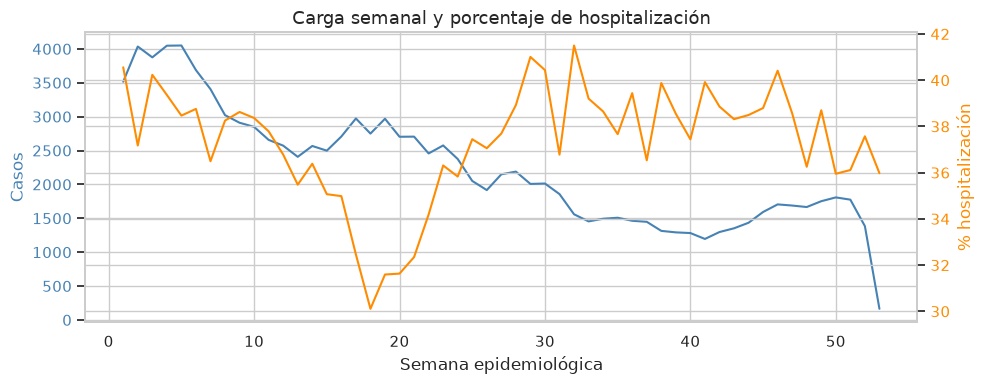

In [36]:
# Vista agregada: carga semanal vs % hospitalización
resumen_semana = (
    df_limpio.groupby("SEMANA")
    .agg(casos=("CONSECUTIVE", "count"), pct_hospitalizado=("hospitalizado", "mean"))
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(resumen_semana["SEMANA"], resumen_semana["casos"], color="steelblue", label="Casos")
ax1.set_xlabel("Semana epidemiológica")
ax1.set_ylabel("Casos", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(
    resumen_semana["SEMANA"],
    resumen_semana["pct_hospitalizado"] * 100,
    color="darkorange",
    label="% hospitalización",
)
ax2.set_ylabel("% hospitalización", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

plt.title("Carga semanal y porcentaje de hospitalización")
plt.tight_layout()
plt.show()


> **Lectura rápida (serie agregada):** los **casos** bajan tras el pico inicial (H1), pero el **% de hospitalización** oscila ~30–42 % y no cae al mismo ritmo. Cuando hay pocos casos al final del año, la proporción hospitalizada puede seguir alta o volátil: volumen ≠ severidad relativa.


## 7.3. Casos por territorio y perfil clínico

**Preguntas guía (H2 / perfil clínico):**
- ¿El % de hospitalización cambia entre departamentos de alta carga?
- ¿Edad media y hospitalización difieren por sexo?

Se responden con las tablas/gráficos de las celdas siguientes.


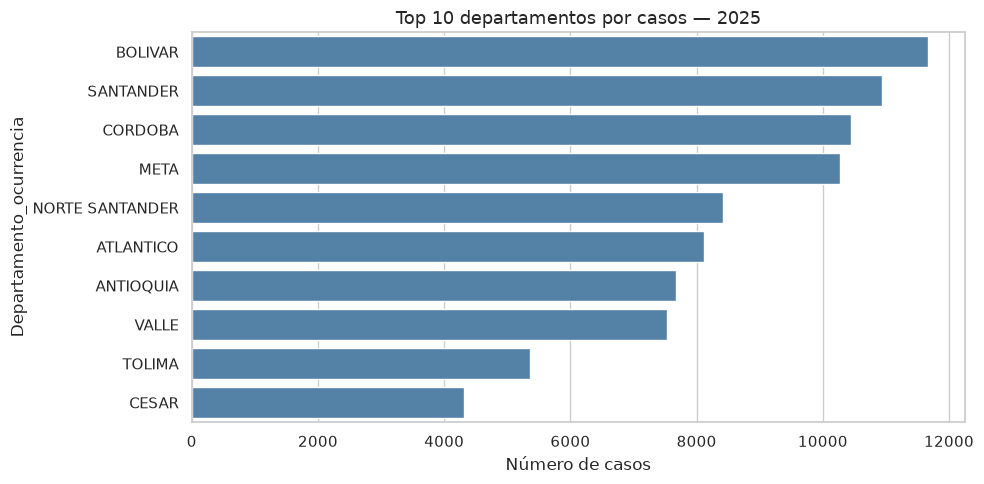

In [25]:
top_deptos = df_limpio["Departamento_ocurrencia"].value_counts().head(10).index
df_top = df_limpio[df_limpio["Departamento_ocurrencia"].isin(top_deptos)]

sns.countplot(data=df_top, y="Departamento_ocurrencia", order=top_deptos, color="steelblue")
plt.title(f"Top 10 departamentos por casos — {ANIO}")
plt.xlabel("Número de casos")
plt.tight_layout()
plt.show()

> **Lectura rápida:** pocos departamentos concentran muchos casos; el ranking visual confirma heterogeneidad territorial (**H2**).


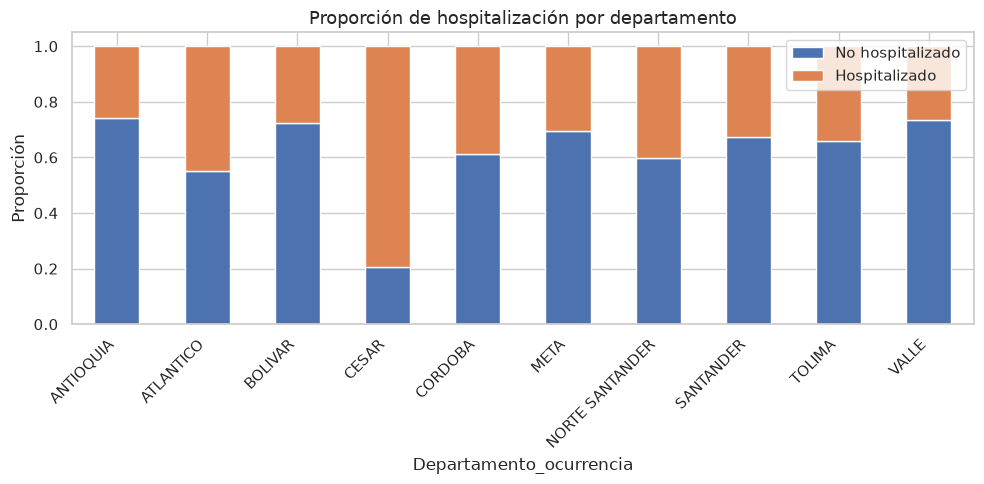

,No hospitalizado,Hospitalizado
Departamento_ocurrencia,,
ANTIOQUIA,0.743,0.257
ATLANTICO,0.552,0.448
BOLIVAR,0.724,0.276
CESAR,0.206,0.794
CORDOBA,0.613,0.387
META,0.695,0.305
NORTE SANTANDER,0.596,0.404
SANTANDER,0.674,0.326
TOLIMA,0.660,0.340


In [32]:
# Hospitalización por departamento (top 10)
tabla_hosp = pd.crosstab(
    df_top["Departamento_ocurrencia"],
    df_top["hospitalizado"],
    normalize="index",
)
tabla_hosp.columns = ["No hospitalizado", "Hospitalizado"]
tabla_hosp.plot(kind="bar", stacked=True, title="Proporción de hospitalización por departamento")
plt.ylabel("Proporción")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()
tabla_hosp.round(3)

> **Lectura rápida:** la proporción de hospitalización **no es igual** entre departamentos del top 10: hay territorios con mayor carga clínica relativa (refuerza **H2**).


In [ ]:
# Edad media y % hospitalización por sexo
resumen_sexo = df_limpio.groupby("SEXO").agg(
    casos=("CONSECUTIVE", "count"),
    edad_media=("edad_anios", "mean"),
    pct_hospitalizado=("hospitalizado", "mean"),
    pct_confirmado=("confirmado", "mean"),
).round(3)
resumen_sexo

,casos,edad_media,pct_hospitalizado,pct_confirmado
SEXO,,,,
F,57626,22.902,0.374,0.752
M,62938,22.108,0.370,0.749


> **Lectura rápida (sexo):** edad media y % hospitalización/% confirmados son **similares entre M y F** a nivel nacional; el sexo solo no explica grandes diferencias de carga clínica.


## 7.4. Estacionalidad y brotes (H1)

**Hipótesis H1:** existe estacionalidad (concentración en ciertos meses/semanas).

**Pregunta guía:** ¿El patrón temporal se mantiene al desagregar por área (urbana/rural)?  
Ejecutar el gráfico apilado mes × área; la lectura va en la síntesis §7 (celda de interpretación bivariada).


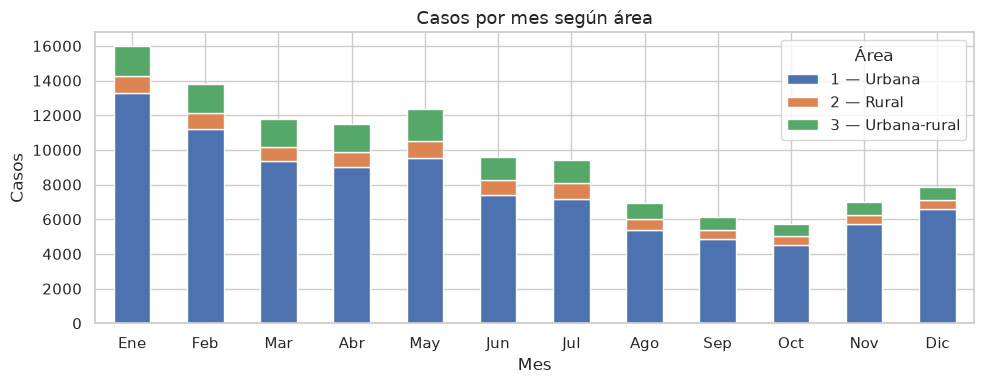

In [ ]:
# Casos por mes y por área (urbana/rural)
area_map = {1: "1 — Urbana", 2: "2 — Rural", 3: "3 — Urbana-rural"}
mes_map = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic",
}

casos_mes_area = pd.crosstab(df_limpio["mes"], df_limpio["AREA"]).sort_index()
casos_mes_area = casos_mes_area.rename(columns=area_map)

ax = casos_mes_area.plot(kind="bar", stacked=True, title="Casos por mes según área", figsize=(10, 4))
ax.set_xlabel("Mes")
ax.set_ylabel("Casos")
ax.set_xticklabels([mes_map.get(m, str(m)) for m in casos_mes_area.index], rotation=0)
plt.legend(title="Área")
plt.tight_layout()
plt.show()

> **Lectura rápida:** el pico de inicio de año se ve también por área; **urbana** concentra la mayor parte de los casos en todos los meses (H1 + contexto territorial).


## 7.5. Análisis territorial (H2) — ranking

**Hipótesis H2:** heterogeneidad territorial (pocos territorios concentran más casos).

No construimos mapas con shapefiles. El entregable es el **ranking** depto/municipio por conteo (celda siguiente): suficiente para confirmar H2 con el Excel 2025.


In [31]:
# Top 15 municipios por casos
top_mun = (
    df_limpio.groupby(["Departamento_ocurrencia", "Municipio_ocurrencia"])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="casos")
)
top_mun

,Departamento_ocurrencia,Municipio_ocurrencia,casos
0,BOLIVAR,CARTAGENA,6848
1,META,VILLAVICENCIO,5401
2,CORDOBA,MONTERIA,4870
3,NORTE SANTANDER,CUCUTA,4735
4,ATLANTICO,BARRANQUILLA,3526
5,SANTANDER,BUCARAMANGA,3197
6,VALLE,CALI,3013
7,SANTANDER,FLORIDABLANCA,1687
8,ATLANTICO,SOLEDAD,1668
9,MAGDALENA,SANTA MARTA,1617


## 7.6. Perfil demográfico en Valle del Cauca (H3)

**Hipótesis H3:** en Valle del Cauca el perfil demográfico (`edad_anios`, `SEXO`) y la hospitalización difieren del agregado nacional.

**Preguntas guía:**
- ¿Cuántos casos hay en Valle y qué % del total representan?
- ¿Edad media/mediana y % hosp. en Valle vs nacional?
- ¿El sexo está equilibrado en Valle?

Se responden al ejecutar la celda de código siguiente; la lectura está en la markdown inmediatamente después.


In [8]:
# H3 — Valle del Cauca (perfil demográfico y hospitalización)
df_valle = df_limpio[df_limpio["Departamento_ocurrencia"].astype(str) == "VALLE"].copy()

print(f"Casos en VALLE: {len(df_valle):,} ({len(df_valle)/len(df_limpio)*100:.1f}% del total {ANIO})")
print(f"Edad media VALLE: {df_valle['edad_anios'].mean():.1f} | mediana: {df_valle['edad_anios'].median():.1f}")
print(f"Hospitalización VALLE: {df_valle['hospitalizado'].mean()*100:.1f}%")
print(f"Confirmados VALLE: {df_valle['confirmado'].mean()*100:.1f}%")
print()

print("--- Sexo en VALLE ---")
print(df_valle["SEXO"].value_counts(normalize=True).mul(100).round(1))
print()

resumen_valle = (
    df_valle.groupby("SEXO")
    .agg(
        casos=("CONSECUTIVE", "count"),
        edad_media=("edad_anios", "mean"),
        pct_hospitalizado=("hospitalizado", "mean"),
        pct_confirmado=("confirmado", "mean"),
    )
    .round(3)
)
display(resumen_valle)

# Comparación visual: distribución de edad nacional vs Valle
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
df_limpio["edad_anios"].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title(f"Edad — Nacional {ANIO}")
axes[0].set_xlabel("edad_anios")
df_valle["edad_anios"].hist(bins=30, ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Edad — VALLE")
axes[1].set_xlabel("edad_anios")
plt.tight_layout()
plt.show()

# Hospitalización por sexo: nacional vs Valle
cmp = pd.DataFrame({
    "Nacional": df_limpio.groupby("SEXO")["hospitalizado"].mean() * 100,
    "VALLE": df_valle.groupby("SEXO")["hospitalizado"].mean() * 100,
}).round(1)
cmp.plot(kind="bar", title="% hospitalización por sexo — Nacional vs VALLE")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
display(cmp)


Casos en VALLE: 7,441 (6.3% del total 2025)
Edad media VALLE: 28.4 | mediana: 24.0
Hospitalización VALLE: 26.5%
Confirmados VALLE: 46.3%

--- Sexo en VALLE ---
SEXO
F    50.2
M    49.8


**Lectura H3 (Valle del Cauca, 2025):**

- Valle aporta **~7.4k casos (~6.3 %** del total nacional tras el filtro de fechas).
- **Histograma edad:** en Valle la masa se desplaza a edades más altas que el total nacional (media ~28.4, mediana 24 vs ~22.5 / 16).
- **Barras % hosp. por sexo:** la hospitalización en Valle (~26.5 %) es **menor** que la nacional (~37 %); F y M se comportan parecido.
- Sexo casi equilibrado (~50/50), a diferencia del leve predominio masculino nacional.
- **Conclusión H3:** perfil demográfico/clínico distinto al agregado país → priorizar análisis **por territorio**.


**Interpretación bivariada (síntesis) — cierre de preguntas e hipótesis:**

| Hipótesis | Preguntas que cierra | Resultado | Evidencia en el notebook |
|-----------|----------------------|-----------|---------------------------|
| **H1** | Distribución por mes/semana; patrón por área | **Confirmada** | §§ 6.1 y 7.4: pico ene–feb / primeras semanas; valle ~oct |
| **H2** | Departamentos/municipios con más casos; hosp. por territorio | **Confirmada** | §§ 6.3, 7.3 y 7.5: Bolívar, Santander, Córdoba; top 10 ≈ 70 % |
| **H3** | Perfil edad/sexo/hosp. en Valle vs nacional | **Confirmada** (vs nacional) | § 7.6: edad ↑, sexo equilibrado, hosp. ↓ |

**Notas de lectura:**
- Correlación `SEMANA`–`mes` es alta **por construcción**; no es un hallazgo epidemiológico.
- Dispersión edad×semana: no separa bien hospitalizados a nivel individual → conviene tasas agregadas.
- Alcance: solo `Datos_2025_210.xlsx` (SIVIGILA 2025).


---
# 8. Conclusiones

> *Etapa del flujo: **Conclusiones***

La pregunta SMART del **proyecto** (visión) es:

> ¿Puede un sistema de analítica predictiva basado en IA anticipar brotes de dengue con precisión > 80 %, reduciendo ≥ 20 % la mortalidad y ≥ 30 % el tiempo de respuesta sanitaria en un piloto de 6 meses?

En este taller **no medimos** esas metas. Lo que sí respondemos con el Excel 2025 son los **KPI del EDA**: volumen y estacionalidad de casos, % confirmados / hospitalización, concentración territorial y perfil Valle vs nacional.

## 8.1. Contraste de las hipótesis

| Hipótesis | Enunciado | Resultado | Evidencia |
|-----------|-----------|-----------|-----------|
| **H1** | Estacionalidad en meses/semanas | **Confirmada** | §§ 6.1 y 7.4: pico ene–feb / semanas iniciales; valle hacia oct. |
| **H2** | Heterogeneidad territorial (casos / hosp.) | **Confirmada** | §§ 6.3, 7.3 y 7.5: Bolívar, Santander, Córdoba; top 10 ≈ 70 %. |
| **H3** | Perfil demográfico distinto en Valle del Cauca | **Confirmada** (vs nacional) | § 7.6: edad ↑, sexo equilibrado, hosp. ↓. |

> **Fuente:** solo `data/raw/Datos_2025_210.xlsx`. Precisión del modelo, mortalidad y tiempos de respuesta quedan para fases posteriores.

## 8.2. Sobre la calidad del conjunto de datos

- **Complejidad concreta:** ~**118k** (tras filtrar `FEC_NOT` fuera de 2025; crudo ≈120.5k) filas × ~**70** columnas; códigos enteros (`PAC_HOS`, `AREA`, `UNI_MED`); fechas en texto; nulos estructurales (`FEC_DEF`, campos vacíos).
- **Completitud:** variables críticas (`FEC_NOT`, territorio, `SEXO`, `EDAD`) bien pobladas. Excluimos columnas ~100 % nulas y `COD_ASE`. Conservamos `FEC_HOS` con nulos esperables.
- **Formato:** fechas parseadas; filtramos `FEC_NOT` fuera de 2025; derivamos `edad_anios`, `mes`, `hospitalizado`, `confirmado`.
- **Relevancia para un modelo futuro sobre esta fuente:** tiempo (`SEMANA`/`mes`), territorio y perfil (`edad_anios`, `SEXO`, hospitalización).

## 8.3. Limitaciones y recomendaciones

- Cubrimos **un solo año** (2025) y **una sola fuente** (Excel SIVIGILA).
- **`FEC_DEF` 100 % nulo** → no analizamos mortalidad con este archivo.
- Siguiente paso (aún sobre SIVIGILA): agregar a **municipio–semana** y entrenar una **regresión de casos**; evaluar desempeño en un horizonte de prueba.

## 8.4. Respuesta a la pregunta de negocio

Con el Excel 2025 observamos **estacionalidad**, **concentración territorial** y un **perfil demográfico que varía por departamento** (caso Valle). Eso **sí apoya** priorizar territorios y ventanas temporales en un piloto de vigilancia.

No afirmamos aún precisión > 80 %, reducción de mortalidad ni de tiempo de respuesta: eso exige **modelado** y variables que este archivo no trae. Nosotros dejamos el EDA listo como base para esa fase.


---
# 9. Evidencia de uso de IA generativa y justificación

**Grupo 3 — integrantes**

| Integrante |
|------------|
| Juan Manuel Román Villa |
| Dora Valencia Martínez |
| Julian Aguilar Mayorga |
| Camilo Percy Ocampo |
| Viviana Fernández Payan |
| Giovanni Jaramillo Bolaños |
| Victor Manuel Hurtado López |

## 9.1. Por qué usamos ciencia de datos / IA (resumen)

EDA ahora para validar calidad, temporalidad, territorio y perfil demográfico. Después: regresión agregada municipio–semana sobre SIVIGILA. La predicción es pertinente porque la carga **no es uniforme** en el tiempo ni en el espacio (hallazgos 2025: pico ene–feb; top 10 ≈ 70 % de casos; Valle distinto al nacional).

## 9.2. Evidencia de uso de IA generativa

| Pregunta | Respuesta |
|----------|-----------|
| **Herramienta usada** | Cursor (agente de código) |
| **Qué partes asistió la IA** | Estructura del notebook alineada a la guía; utilidades de carga/limpieza; gráficos EDA; corrección de tipos; análisis H3 Valle; ajuste de alcance a Excel 2025; borradores de interpretaciones |
| **Qué validamos nosotros** | Hipótesis H1–H3; diccionario SIVIGILA; cifras (confirmados ≈ 75 %, hosp. ≈ 37 %, top deptos, Valle); coherencia del alcance (sin medir mortalidad en este taller); re-ejecución de celdas clave |
| **Iteraciones relevantes** | KPI medibles vs visión SMART; filtrado de `FEC_NOT` fuera de 2025; Expectativa Alta/Media/Baja en el diccionario; cierre de §§ 7–9 en voz de equipo |
